# ANÁLISIS DEL EFECTO DEL AUMENTO DEL PARQUE VEHICULAR LIVIANO Y EL DETERIORO DE LA CALIDAD DEL AIRE CON PM2.5 EN LA CIUDAD CAPITAL, GUATEMALA 2022-2025

**Metodología:** CRISP-DM  
**Variable endógena:** PM2.5 mensual promedio, medida en μg/m³.  
**Variable explicativa principal:** parque vehicular liviano mensual construido con la suma de CANTIDAD.  
**Controles:** temperatura media, precipitación, velocidad del viento y humedad relativa.

Este notebook es una base analítica reproducible para una investigación de maestría. Integra datos con periodicidades distintas, los transforma a frecuencia mensual y compara dos modelos de series de tiempo con variables exógenas: ARIMAX y SARIMAX.

> Nota crítica: en el dataset vehicular, cada fila representa un grupo de vehículos. Por tanto, el parque vehicular se calcula sumando la columna CANTIDAD; no se calcula contando filas.

# Fase 1: Business Understanding

## Objetivo del proyecto

Estimar si el aumento del parque vehicular liviano está asociado estadísticamente con cambios en los niveles mensuales de PM2.5 en la Ciudad Capital de Guatemala durante 2022-2025.

## Pregunta de investigación operativa

¿Existe una relación estadísticamente significativa entre el crecimiento del parque vehicular liviano y la concentración mensual promedio de PM2.5, controlando por estacionalidad y por condiciones climatológicas?

## Métricas de éxito

Se utilizarán métricas de ajuste penalizado y de error fuera de muestra:

- AIC: menor valor indica mejor balance entre ajuste y complejidad.
- BIC: similar a AIC, pero penaliza más la complejidad.
- RMSE: error cuadrático medio, sensible a errores grandes.
- MAE: error absoluto medio, interpretable en unidades de PM2.5.

## Enfoque estadístico

La estrategia se basa en modelos de regresión dinámica para series de tiempo:

- Modelo 1, ARIMAX: PM2.5 como variable endógena y parque vehicular como variable exógena.
- Modelo 2, SARIMAX: PM2.5 como variable endógena, parque vehicular y clima como variables exógenas, con estacionalidad anual mensual s = 12.

La significancia estadística del parque vehicular se evaluará con el p-valor de su coeficiente. Un p-valor menor a 0.05 se interpretará como evidencia estadística al 5%, dentro de la especificación del modelo.

In [52]:
# ============================================================
# Verificacion e instalacion automatica de dependencias
# ============================================================

import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "statsmodels": "statsmodels",
}

missing_packages = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module_name) is None]

if missing_packages:
    print("Instalando dependencias faltantes:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Todas las dependencias requeridas est?n disponibles.")



Todas las dependencias requeridas est?n disponibles.


In [53]:
# ============================================================
# Configuración inicial
# ============================================================

from __future__ import annotations

import itertools
import re
import unicodedata
import warnings
from pathlib import Path
from typing import Iterable, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"

VEHICLE_CANDIDATES = [
    DATA_DIR / "Vehiculos" / "PARQUE-VEHICULAR-LIVIANO-2007-2025-FULL.csv",
    DATA_DIR / "Vehiculos" / "PARQUE-VEHICULAR-2007-2025-FULL.csv",
    PROJECT_ROOT / "PARQUE-VEHICULAR-LIVIANO-2007-2025-FULL.csv",
]
PM25_CANDIDATES = [DATA_DIR / "PM25" / "PM25_DAIRY_FULL_2022_2025.csv", PROJECT_ROOT / "PM25_DAIRY_FULL_2022_2025.csv"]
CLIMATE_CANDIDATES = [DATA_DIR / "Test" / "CLIMA_2022_2025.csv", PROJECT_ROOT / "CLIMA_2022_2025.csv"]
RANDOM_STATE = 42

In [54]:
# ============================================================
# Funciones utilitarias reutilizables
# ============================================================

def find_existing_path(candidates: Sequence[Path]) -> Path:
    """Devuelve la primera ruta existente dentro de una lista de candidatas."""
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("No se encontró ningún archivo en las rutas candidatas:\n" + "\n".join(map(str, candidates)))


def read_csv_smart(path: Path) -> pd.DataFrame:
    """Carga CSV probando codificaciones frecuentes en fuentes oficiales latinoamericanas."""
    last_error = None
    for encoding in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError as exc:
            last_error = exc
    raise UnicodeDecodeError(f"No se pudo leer {path}. Último error: {last_error}")


def normalize_column_name(column: str) -> str:
    """Normaliza nombres de columnas: mayúsculas, sin tildes y con guiones bajos."""
    text = str(column).strip()
    try:
        text = text.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    return re.sub(r"[^0-9A-Za-z]+", "_", text).strip("_").upper()


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    output = df.copy()
    output.columns = [normalize_column_name(col) for col in output.columns]
    return output


def month_start(date_like) -> pd.Timestamp:
    return pd.Timestamp(date_like).to_period("M").to_timestamp()


def quick_overview(df: pd.DataFrame, name: str) -> None:
    print(f"\n{'=' * 80}\nDataset: {name}")
    print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nValores nulos por columna:")
    print(df.isna().sum().sort_values(ascending=False))
    print("\nPrimeras filas:")
    display(df.head())
    print("\nResumen numérico:")
    display(df.describe(include="number").T)


def assert_required_columns(df: pd.DataFrame, required: set[str], dataset_name: str) -> None:
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"Faltan columnas en {dataset_name}: {missing}")
    print(f"Columnas requeridas presentes en {dataset_name}.")


def adf_test(series: pd.Series, variable_name: str) -> dict:
    clean_series = pd.to_numeric(series, errors="coerce").dropna()
    if clean_series.nunique() <= 1 or len(clean_series) < 10:
        return {"variable": variable_name, "n_obs": len(clean_series), "adf_statistic": np.nan, "p_value": np.nan, "used_lag": np.nan, "is_stationary_5pct": False, "interpretation": "No evaluable"}
    result = adfuller(clean_series, autolag="AIC")
    p_value = result[1]
    return {"variable": variable_name, "n_obs": len(clean_series), "adf_statistic": result[0], "p_value": p_value, "used_lag": result[2], "is_stationary_5pct": bool(p_value < 0.05), "interpretation": "Estacionaria" if p_value < 0.05 else "No estacionaria"}


def run_adf_suite(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    return pd.DataFrame([adf_test(df[col], col) for col in columns if col in df.columns]).sort_values("p_value", na_position="last")


def train_test_time_split(df: pd.DataFrame, test_periods: int = 12) -> tuple[pd.DataFrame, pd.DataFrame]:
    if len(df) <= test_periods + 12:
        test_periods = max(6, int(round(len(df) * 0.2)))
    return df.iloc[:-test_periods].copy(), df.iloc[-test_periods:].copy()


def scale_exog(train_exog: pd.DataFrame, test_exog: pd.DataFrame, full_exog: pd.DataFrame):
    scaler = StandardScaler()
    scaler.fit(train_exog)
    train_scaled = pd.DataFrame(scaler.transform(train_exog), index=train_exog.index, columns=train_exog.columns)
    test_scaled = pd.DataFrame(scaler.transform(test_exog), index=test_exog.index, columns=test_exog.columns)
    full_scaled = pd.DataFrame(scaler.transform(full_exog), index=full_exog.index, columns=full_exog.columns)
    return train_scaled, test_scaled, full_scaled, scaler


def fit_sarimax_model(y: pd.Series, exog: Optional[pd.DataFrame], order: tuple[int, int, int], seasonal_order: tuple[int, int, int, int] = (0, 0, 0, 0)):
    model = SARIMAX(
        endog=y,
        exog=exog,
        order=order,
        seasonal_order=seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
        missing="drop",
    )
    return model.fit(disp=False, maxiter=300)


def sarimax_grid_search(y: pd.Series, exog: Optional[pd.DataFrame], p_values: Iterable[int], d_values: Iterable[int], q_values: Iterable[int], seasonal_orders: Iterable[tuple[int, int, int, int]], criterion: str = "aic") -> pd.DataFrame:
    rows = []
    for order in itertools.product(p_values, d_values, q_values):
        for seasonal_order in seasonal_orders:
            try:
                fitted = fit_sarimax_model(y, exog, order=order, seasonal_order=seasonal_order)
                rows.append({"order": order, "seasonal_order": seasonal_order, "aic": fitted.aic, "bic": fitted.bic, "converged": bool(fitted.mle_retvals.get("converged", False))})
            except Exception as exc:
                rows.append({"order": order, "seasonal_order": seasonal_order, "aic": np.inf, "bic": np.inf, "converged": False, "error": str(exc)[:120]})
    return pd.DataFrame(rows).sort_values(criterion).reset_index(drop=True)


def rmse(y_true: pd.Series, y_pred: pd.Series) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_forecast(y_true: pd.Series, y_pred: pd.Series, model_name: str) -> dict:
    aligned = pd.concat([y_true.rename("actual"), y_pred.rename("predicted")], axis=1).dropna()
    return {"model": model_name, "n_test": len(aligned), "rmse": rmse(aligned["actual"], aligned["predicted"]), "mae": float(mean_absolute_error(aligned["actual"], aligned["predicted"]))}


def coefficient_table(results, alpha: float = 0.05) -> pd.DataFrame:
    conf_int = results.conf_int()
    table = pd.DataFrame({"coef": results.params, "std_error": results.bse, "z_or_t": results.tvalues, "p_value": results.pvalues, "ci_lower": conf_int.iloc[:, 0], "ci_upper": conf_int.iloc[:, 1]})
    table["significant_5pct"] = table["p_value"] < alpha
    return table

# Fase 2: Data Understanding

En esta fase se cargan los tres datasets oficiales y se revisa su estructura: tipos de datos, valores nulos, rangos temporales, distribuciones y series crudas. Esta exploración permite detectar problemas de codificación, fechas inválidas y columnas numéricas leídas como texto.

In [55]:
# ============================================================
# Carga, validación y EDA preliminar
# ============================================================

vehicle_path = find_existing_path(VEHICLE_CANDIDATES)
pm25_path = find_existing_path(PM25_CANDIDATES)
climate_path = find_existing_path(CLIMATE_CANDIDATES)

print("Archivo vehicular:", vehicle_path)
print("Archivo PM2.5:", pm25_path)
print("Archivo clima:", climate_path)

vehicle_raw = normalize_columns(read_csv_smart(vehicle_path))
pm25_raw = normalize_columns(read_csv_smart(pm25_path))
climate_raw = normalize_columns(read_csv_smart(climate_path))

REQUIRED_VEHICLE_COLUMNS = {"ANIO_ALZA", "MES", "MODELO_VEHICULO", "LINEA_VEHICULO", "TIPO_VEHICULO", "USO_VEHICULO", "MARCA_VEHICULO", "CANTIDAD"}
REQUIRED_PM25_COLUMNS = {"YEAR", "MONTH", "DAY", "PM25"}
REQUIRED_CLIMATE_COLUMNS = {"FECHA", "TEMPERATURA_MEDIA", "PRECIPITACION", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"}

assert_required_columns(vehicle_raw, REQUIRED_VEHICLE_COLUMNS, "Parque vehicular")
assert_required_columns(pm25_raw, REQUIRED_PM25_COLUMNS, "PM2.5")
assert_required_columns(climate_raw, REQUIRED_CLIMATE_COLUMNS, "Clima")

quick_overview(vehicle_raw, "Parque vehicular")
quick_overview(pm25_raw, "PM2.5 diario")
quick_overview(climate_raw, "Clima diario")

Archivo vehicular: C:\Users\james\Documents\Github\air-quality-vehicular-impact-analysis\Data\Vehiculos\PARQUE-VEHICULAR-2007-2025-FULL.csv
Archivo PM2.5: C:\Users\james\Documents\Github\air-quality-vehicular-impact-analysis\Data\PM25\PM25_DAIRY_FULL_2022_2025.csv
Archivo clima: C:\Users\james\Documents\Github\air-quality-vehicular-impact-analysis\Data\Test\CLIMA_2022_2025.csv
Columnas requeridas presentes en Parque vehicular.
Columnas requeridas presentes en PM2.5.
Columnas requeridas presentes en Clima.

Dataset: Parque vehicular
Dimensiones: 557,454 filas x 8 columnas

Tipos de datos:
ANIO_ALZA          int64
MES                int64
MODELO_VEHICULO      str
LINEA_VEHICULO       str
TIPO_VEHICULO        str
USO_VEHICULO         str
MARCA_VEHICULO       str
CANTIDAD           int64
dtype: object

Valores nulos por columna:
LINEA_VEHICULO     20
ANIO_ALZA           0
MES                 0
MODELO_VEHICULO     0
TIPO_VEHICULO       0
USO_VEHICULO        0
MARCA_VEHICULO      0
CANTIDAD 

,ANIO_ALZA,MES,MODELO_VEHICULO,LINEA_VEHICULO,TIPO_VEHICULO,USO_VEHICULO,MARCA_VEHICULO,CANTIDAD
0,2007,5,2003,SANTA FE V6 4X2,CAMIONETA,PARTICULAR,HYUNDAI,1
1,2007,5,2001,SWIFT,AUTOMOVIL,PARTICULAR,SUZUKI,1
2,2007,5,1995,METRO LSI,AUTOMOVIL,PARTICULAR,GEO,1
3,2007,5,2003,JETTA,AUTOMOVIL,PARTICULAR,VOLKSWAGEN,1
4,2007,5,2007,5,CAMIONETA,PARTICULAR,MAZDA,5



Resumen numérico:


,count,mean,std,min,25%,50%,75%,max
ANIO_ALZA,"557,454.0000","2,012.5458",9.7378,"1,980.0000","2,006.0000","2,015.0000","2,021.0000","2,025.0000"
MES,"557,454.0000",6.5319,3.5254,1.0000,3.0000,7.0000,10.0000,12.0000
CANTIDAD,"557,454.0000",2.7514,14.3432,1.0000,1.0000,1.0000,2.0000,"1,889.0000"



Dataset: PM2.5 diario
Dimensiones: 1,380 filas x 4 columnas

Tipos de datos:
YEAR       int64
MONTH      int64
DAY        int64
PM25     float64
dtype: object

Valores nulos por columna:
YEAR     0
MONTH    0
DAY      0
PM25     0
dtype: int64

Primeras filas:


...

,count,mean,std,min,25%,50%,75%,max
YEAR,"1,380.0000","2,023.5790",1.0940,"2,022.0000","2,023.0000","2,024.0000","2,025.0000","2,025.0000"
MONTH,"1,380.0000",6.7884,3.3516,1.0000,4.0000,7.0000,10.0000,12.0000
DAY,"1,380.0000",15.7920,8.8263,1.0000,8.0000,16.0000,23.0000,31.0000
PM25,"1,380.0000",30.4328,42.2411,0.8000,9.1000,18.1500,37.1250,"1,016.0000"



Dataset: Clima diario
Dimensiones: 1,461 filas x 6 columnas

Tipos de datos:
FECHA                    str
NOMBRE_ESTACION          str
TEMPERATURA_MEDIA    float64
PRECIPITACION        float64
VELOCIDAD_VIENTO     float64
HUMEDAD_RELATIVA       int64
dtype: object

Valores nulos por columna:
FECHA                0
NOMBRE_ESTACION      0
TEMPERATURA_MEDIA    0
PRECIPITACION        0
VELOCIDAD_VIENTO     0
HUMEDAD_RELATIVA     0
dtype: int64

Primeras filas:


,FECHA,NOMBRE_ESTACION,TEMPERATURA_MEDIA,PRECIPITACION,VELOCIDAD_VIENTO,HUMEDAD_RELATIVA
0,2022-01-01,INSIVUMEH,20.3000,0.0000,8.6000,76
1,2022-01-02,INSIVUMEH,20.2000,0.0000,10.0000,77
2,2022-01-03,INSIVUMEH,19.1000,0.0000,24.7000,78
3,2022-01-04,INSIVUMEH,17.5000,0.5000,29.7000,73
4,2022-01-05,INSIVUMEH,19.0000,0.0000,18.7000,65



Resumen numérico:


,count,mean,std,min,25%,50%,75%,max
TEMPERATURA_MEDIA,"1,461.0000",20.7233,1.6919,14.0000,19.6000,20.8000,22.0000,25.7000
PRECIPITACION,"1,461.0000",3.5554,9.3995,0.0000,0.0000,0.0000,1.4000,83.5000
VELOCIDAD_VIENTO,"1,461.0000",6.3384,5.5400,0.0000,3.3000,4.7000,7.3000,60.7000
HUMEDAD_RELATIVA,"1,461.0000",75.0185,7.7033,51.0000,70.0000,75.0000,80.0000,96.0000


Rango vehicular: 1980-01-01 00:00:00 a 2025-12-01 00:00:00
Rango PM2.5: 2022-03-04 00:00:00 a 2025-12-31 00:00:00
Rango clima: 2022-01-01 00:00:00 a 2025-12-31 00:00:00


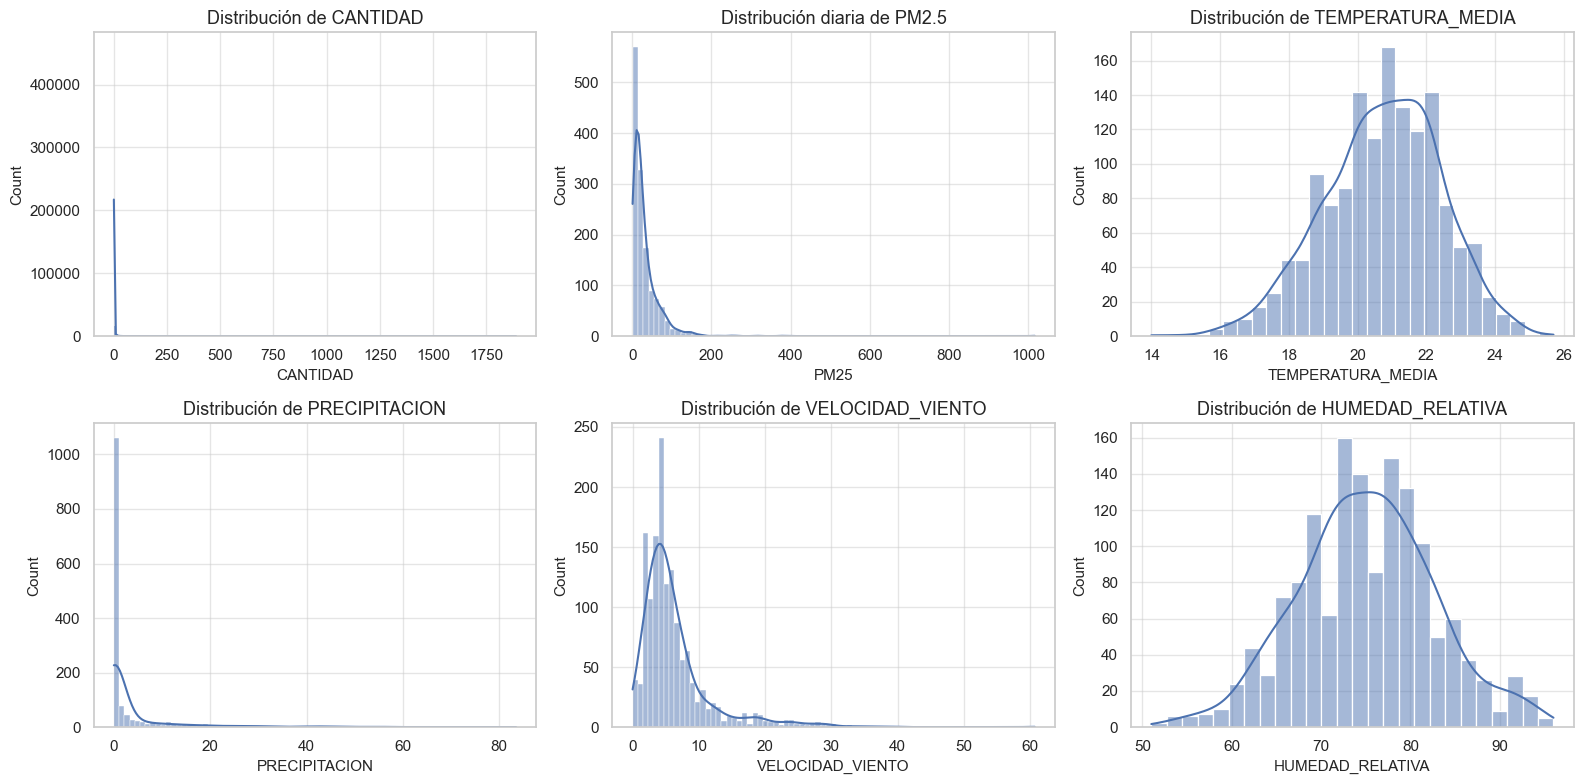

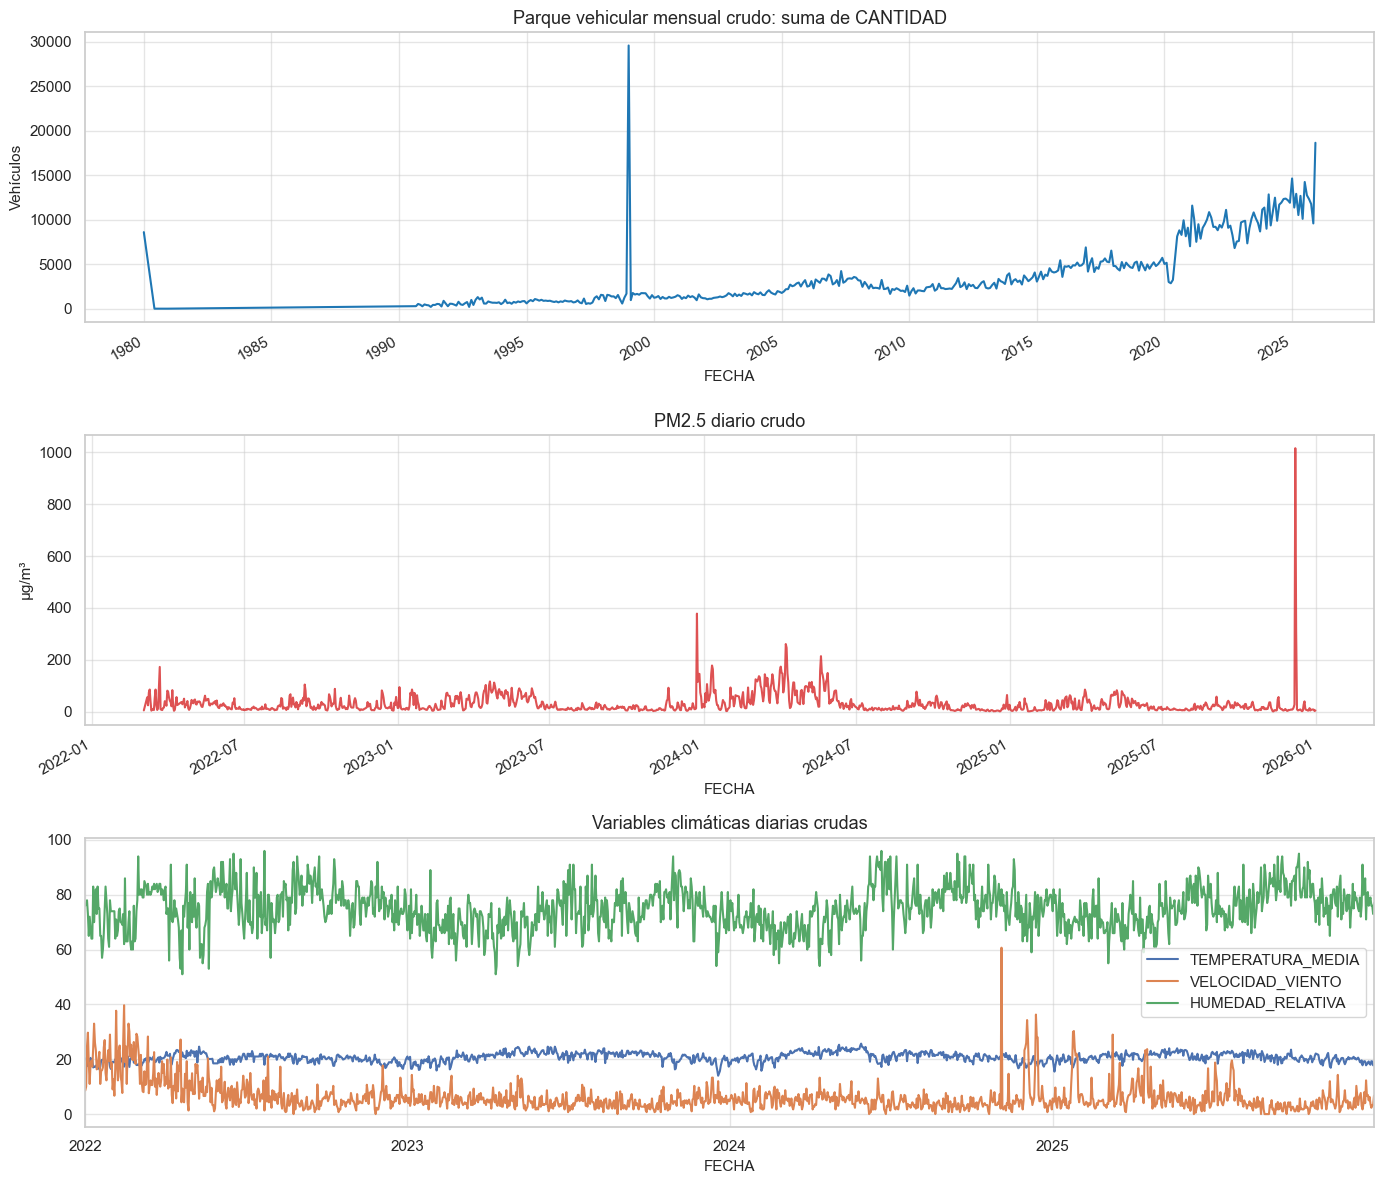

In [56]:
# ============================================================
# Conversión de fechas y gráficos crudos
# ============================================================

vehicle_eda = vehicle_raw.copy()
vehicle_eda["ANIO_ALZA"] = pd.to_numeric(vehicle_eda["ANIO_ALZA"], errors="coerce")
vehicle_eda["MES"] = pd.to_numeric(vehicle_eda["MES"], errors="coerce")
vehicle_eda["CANTIDAD"] = pd.to_numeric(vehicle_eda["CANTIDAD"], errors="coerce")
vehicle_eda["FECHA"] = pd.to_datetime(dict(year=vehicle_eda["ANIO_ALZA"], month=vehicle_eda["MES"], day=1), errors="coerce")

pm25_eda = pm25_raw.copy()
for col in ["YEAR", "MONTH", "DAY", "PM25"]:
    pm25_eda[col] = pd.to_numeric(pm25_eda[col], errors="coerce")
pm25_eda["FECHA"] = pd.to_datetime(dict(year=pm25_eda["YEAR"], month=pm25_eda["MONTH"], day=pm25_eda["DAY"]), errors="coerce")

climate_eda = climate_raw.copy()
climate_eda["FECHA"] = pd.to_datetime(climate_eda["FECHA"], errors="coerce")
for col in ["TEMPERATURA_MEDIA", "PRECIPITACION", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]:
    climate_eda[col] = pd.to_numeric(climate_eda[col], errors="coerce")

print("Rango vehicular:", vehicle_eda["FECHA"].min(), "a", vehicle_eda["FECHA"].max())
print("Rango PM2.5:", pm25_eda["FECHA"].min(), "a", pm25_eda["FECHA"].max())
print("Rango clima:", climate_eda["FECHA"].min(), "a", climate_eda["FECHA"].max())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
sns.histplot(vehicle_eda["CANTIDAD"].dropna(), kde=True, ax=axes[0]); axes[0].set_title("Distribución de CANTIDAD")
sns.histplot(pm25_eda["PM25"].dropna(), kde=True, ax=axes[1]); axes[1].set_title("Distribución diaria de PM2.5")
for ax, col in zip(axes[2:], ["TEMPERATURA_MEDIA", "PRECIPITACION", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]):
    sns.histplot(climate_eda[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")
plt.tight_layout(); plt.show()

vehicle_monthly_raw = vehicle_eda.dropna(subset=["FECHA", "CANTIDAD"]).groupby("FECHA")["CANTIDAD"].sum().sort_index()
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
vehicle_monthly_raw.plot(ax=axes[0], color="tab:blue"); axes[0].set_title("Parque vehicular mensual crudo: suma de CANTIDAD"); axes[0].set_ylabel("Vehículos")
pm25_eda.set_index("FECHA")["PM25"].sort_index().plot(ax=axes[1], color="tab:red", alpha=0.8); axes[1].set_title("PM2.5 diario crudo"); axes[1].set_ylabel("μg/m³")
climate_eda.set_index("FECHA")[["TEMPERATURA_MEDIA", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]].sort_index().plot(ax=axes[2]); axes[2].set_title("Variables climáticas diarias crudas")
plt.tight_layout(); plt.show()

In [57]:
pm25_eda.head(1)

,YEAR,MONTH,DAY,PM25,FECHA
0,2022,3,4,4.6000,2022-03-04


# Fase 3: Data Preparation

Esta fase armoniza los tres datasets a frecuencia mensual. El rango final se define por la intersección real de fechas disponibles en PM2.5, clima y parque vehicular.

Decisiones de preparación:

- Parque vehicular: suma mensual de CANTIDAD agrupada por ANIO_ALZA y MES.
- Parque acumulado: suma acumulada desde el inicio histórico disponible para aproximar el stock vehicular.
- PM2.5: promedio mensual.
- Temperatura, viento y humedad: promedio mensual.
- Precipitación: total mensual y promedio mensual. Para el modelo se usa total mensual.
- Índice final: DatetimeIndex mensual con frecuencia MS, primer día de cada mes.

In [58]:
# ============================================================
# Preparación mensual y consolidación
# ============================================================

vehicle = vehicle_raw.copy()
vehicle["ANIO_ALZA"] = pd.to_numeric(vehicle["ANIO_ALZA"], errors="coerce").astype("Int64")
vehicle["MES"] = pd.to_numeric(vehicle["MES"], errors="coerce").astype("Int64")
vehicle["CANTIDAD"] = pd.to_numeric(vehicle["CANTIDAD"], errors="coerce")
vehicle = vehicle.dropna(subset=["ANIO_ALZA", "MES", "CANTIDAD"])
vehicle["FECHA"] = pd.to_datetime(dict(year=vehicle["ANIO_ALZA"].astype(int), month=vehicle["MES"].astype(int), day=1), errors="coerce")
vehicle = vehicle.dropna(subset=["FECHA"])

# Si el archivo no viniera ya filtrado como liviano, activar una lista explícita de tipos.
LIGHT_VEHICLE_TYPES: Optional[list[str]] = None
# Ejemplo: LIGHT_VEHICLE_TYPES = ["AUTOMOVIL", "CAMIONETA", "PICK UP", "PANEL", "MICROBUS"]
if LIGHT_VEHICLE_TYPES is not None:
    vehicle = vehicle[vehicle["TIPO_VEHICULO"].isin(LIGHT_VEHICLE_TYPES)].copy()

vehicle_monthly_full = vehicle.groupby(["ANIO_ALZA", "MES"], as_index=False)["CANTIDAD"].sum()
vehicle_monthly_full["FECHA"] = pd.to_datetime(dict(year=vehicle_monthly_full["ANIO_ALZA"].astype(int), month=vehicle_monthly_full["MES"].astype(int), day=1))
vehicle_monthly_full = vehicle_monthly_full.sort_values("FECHA").set_index("FECHA").asfreq("MS")
vehicle_monthly_full["CANTIDAD"] = vehicle_monthly_full["CANTIDAD"].fillna(0)
vehicle_monthly_full["PARQUE_VEHICULAR_ACUM"] = vehicle_monthly_full["CANTIDAD"].cumsum()
vehicle_monthly_full["CRECIMIENTO_VEHICULAR_MENSUAL"] = vehicle_monthly_full["CANTIDAD"]
vehicle_monthly_full["LOG_PARQUE_VEHICULAR_ACUM"] = np.log1p(vehicle_monthly_full["PARQUE_VEHICULAR_ACUM"])
vehicle_monthly_full["DLOG_PARQUE_VEHICULAR_ACUM"] = vehicle_monthly_full["LOG_PARQUE_VEHICULAR_ACUM"].diff()

pm25 = pm25_raw.copy()
for col in ["YEAR", "MONTH", "DAY", "PM25"]:
    pm25[col] = pd.to_numeric(pm25[col], errors="coerce")
pm25["FECHA"] = pd.to_datetime(dict(year=pm25["YEAR"], month=pm25["MONTH"], day=pm25["DAY"]), errors="coerce")
pm25 = pm25.dropna(subset=["FECHA", "PM25"])
pm25_monthly = pm25.set_index("FECHA").sort_index().resample("MS").agg(PM25=("PM25", "mean"), PM25_MEDIANA=("PM25", "median"), PM25_DIAS_VALIDOS=("PM25", "count"))

climate = climate_raw.copy()
climate["FECHA"] = pd.to_datetime(climate["FECHA"], errors="coerce")
for col in ["TEMPERATURA_MEDIA", "PRECIPITACION", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]:
    climate[col] = pd.to_numeric(climate[col], errors="coerce")
climate = climate.dropna(subset=["FECHA"])
climate_monthly = climate.set_index("FECHA").sort_index().resample("MS").agg(
    TEMPERATURA_MEDIA=("TEMPERATURA_MEDIA", "mean"),
    PRECIPITACION_TOTAL=("PRECIPITACION", "sum"),
    PRECIPITACION_MEDIA=("PRECIPITACION", "mean"),
    VELOCIDAD_VIENTO=("VELOCIDAD_VIENTO", "mean"),
    HUMEDAD_RELATIVA=("HUMEDAD_RELATIVA", "mean"),
    CLIMA_DIAS_VALIDOS=("TEMPERATURA_MEDIA", "count"),
)

start_date = max(month_start(vehicle_monthly_full.index.min()), month_start(pm25_monthly.index.min()), month_start(climate_monthly.index.min()))
end_date = min(month_start(vehicle_monthly_full.index.max()), month_start(pm25_monthly.index.max()), month_start(climate_monthly.index.max()))
monthly_index = pd.date_range(start=start_date, end=end_date, freq="MS")
print(f"Rango mensual consolidado: {start_date.date()} a {end_date.date()}")
print(f"Número de meses: {len(monthly_index)}")

df_monthly = pd.concat([
    pm25_monthly,
    vehicle_monthly_full[["CRECIMIENTO_VEHICULAR_MENSUAL", "PARQUE_VEHICULAR_ACUM", "LOG_PARQUE_VEHICULAR_ACUM", "DLOG_PARQUE_VEHICULAR_ACUM"]],
    climate_monthly,
], axis=1).reindex(monthly_index)
df_monthly.index.name = "FECHA"

print("Valores nulos antes de limpieza final:")
display(df_monthly.isna().sum().to_frame("nulos"))

df_monthly_clean = df_monthly.dropna(subset=["PM25", "PARQUE_VEHICULAR_ACUM", "TEMPERATURA_MEDIA", "PRECIPITACION_TOTAL", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]).copy()
print("Dimensión final:", df_monthly_clean.shape)
display(df_monthly_clean.head())
display(df_monthly_clean.tail())

Rango mensual consolidado: 2022-03-01 a 2025-12-01
Número de meses: 46
Valores nulos antes de limpieza final:


,nulos
PM25,0
PM25_MEDIANA,0
PM25_DIAS_VALIDOS,0
CRECIMIENTO_VEHICULAR_MENSUAL,0
PARQUE_VEHICULAR_ACUM,0
LOG_PARQUE_VEHICULAR_ACUM,0
DLOG_PARQUE_VEHICULAR_ACUM,0
TEMPERATURA_MEDIA,0
PRECIPITACION_TOTAL,0
PRECIPITACION_MEDIA,0


Dimensión final: (46, 13)


,PM25,PM25_MEDIANA,PM25_DIAS_VALIDOS,CRECIMIENTO_VEHICULAR_MENSUAL,PARQUE_VEHICULAR_ACUM,LOG_PARQUE_VEHICULAR_ACUM,DLOG_PARQUE_VEHICULAR_ACUM,TEMPERATURA_MEDIA,PRECIPITACION_TOTAL,PRECIPITACION_MEDIA,VELOCIDAD_VIENTO,HUMEDAD_RELATIVA,CLIMA_DIAS_VALIDOS
FECHA,,,,,,,,,,,,,
2022-03-01,36.2192,22.5000,26.0000,"9,418.0000","1,048,676.0000",13.8630,0.0090,19.4839,2.5000,0.0806,14.5097,82.0000,31.0000
2022-04-01,34.6538,30.1500,26.0000,"9,124.0000","1,057,800.0000",13.8717,0.0087,21.6033,106.6000,3.5533,11.3733,72.4000,30.0000
2022-05-01,35.0429,34.7000,28.0000,"9,811.0000","1,067,611.0000",13.8809,0.0092,21.1355,208.5000,6.7258,9.5355,74.3226,31.0000
2022-06-01,18.1700,16.0000,30.0000,"11,113.0000","1,078,724.0000",13.8913,0.0104,20.0200,336.4000,11.2133,7.4900,80.9000,30.0000
2022-07-01,11.1000,10.1000,31.0000,"9,099.0000","1,087,823.0000",13.8997,0.0084,21.1194,126.9000,4.0935,7.2581,74.8065,31.0000


,PM25,PM25_MEDIANA,PM25_DIAS_VALIDOS,CRECIMIENTO_VEHICULAR_MENSUAL,PARQUE_VEHICULAR_ACUM,LOG_PARQUE_VEHICULAR_ACUM,DLOG_PARQUE_VEHICULAR_ACUM,TEMPERATURA_MEDIA,PRECIPITACION_TOTAL,PRECIPITACION_MEDIA,VELOCIDAD_VIENTO,HUMEDAD_RELATIVA,CLIMA_DIAS_VALIDOS
FECHA,,,,,,,,,,,,,
2025-08-01,15.6290,13.2000,31.0000,"12,756.0000","1,481,441.0000",14.2085,0.0086,21.5484,170.5000,5.5000,3.4710,77.6774,31.0000
2025-09-01,24.1867,23.0000,30.0000,"12,323.0000","1,493,764.0000",14.2168,0.0083,20.5900,380.5000,12.6833,2.2333,84.0333,30.0000
2025-10-01,15.8806,15.7000,31.0000,"11,775.0000","1,505,539.0000",14.2247,0.0079,20.2968,170.2000,5.4903,2.6419,82.3226,31.0000
2025-11-01,12.7733,8.4500,30.0000,"9,590.0000","1,515,129.0000",14.2310,0.0063,19.6633,38.7000,1.2900,5.1000,77.4000,30.0000
2025-12-01,51.5903,7.2000,31.0000,"18,661.0000","1,533,790.0000",14.2433,0.0122,19.4065,23.0000,0.7419,4.9065,77.6774,31.0000


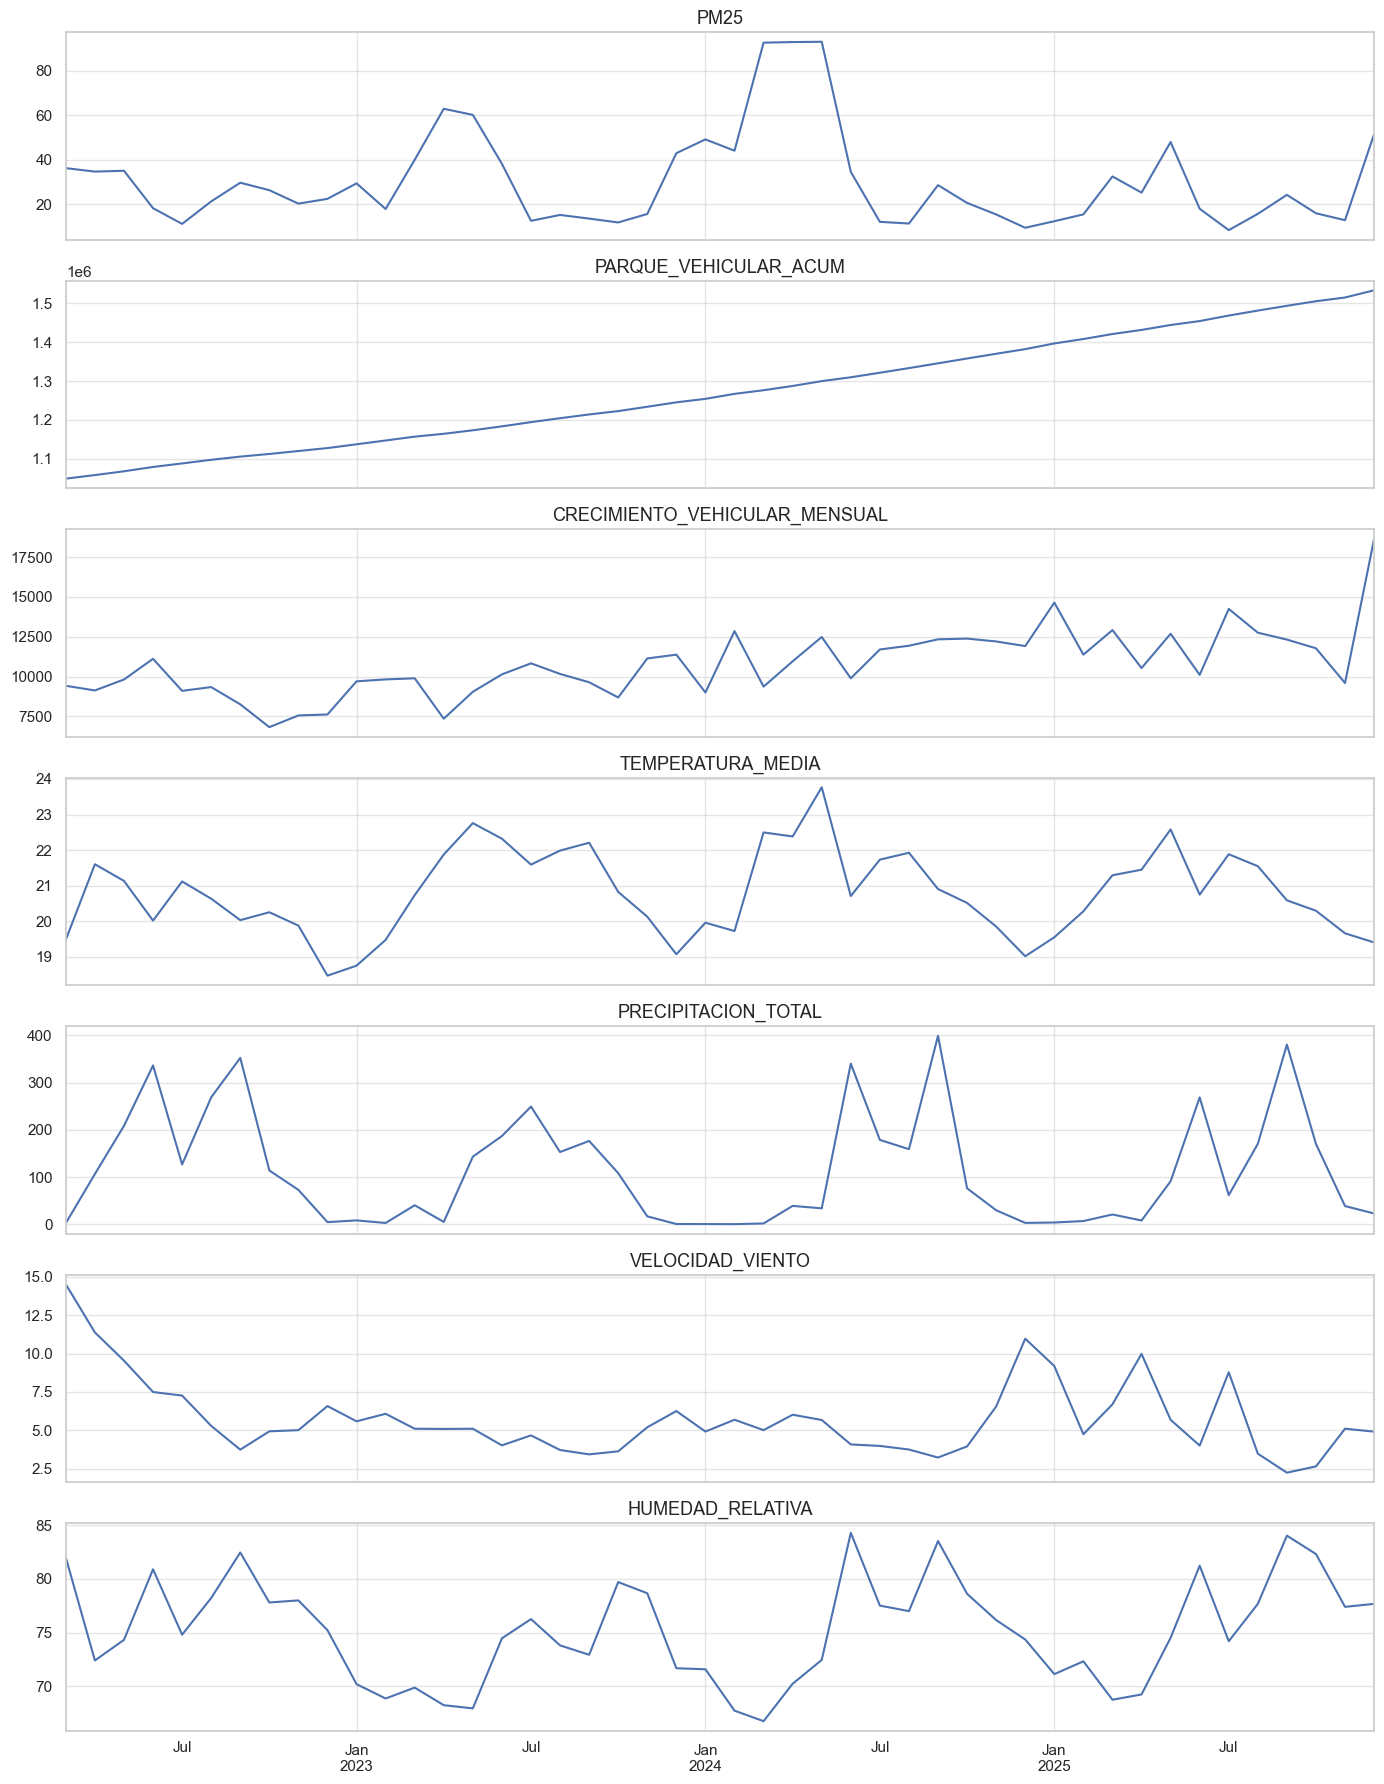

In [59]:
# ============================================================
# Visualización y correlación del dataset mensual consolidado
# ============================================================

plot_cols = ["PM25", "PARQUE_VEHICULAR_ACUM", "CRECIMIENTO_VEHICULAR_MENSUAL", "TEMPERATURA_MEDIA", "PRECIPITACION_TOTAL", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]
fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 18), sharex=True)
for ax, col in zip(axes, plot_cols):
    df_monthly_clean[col].plot(ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout(); plt.show()



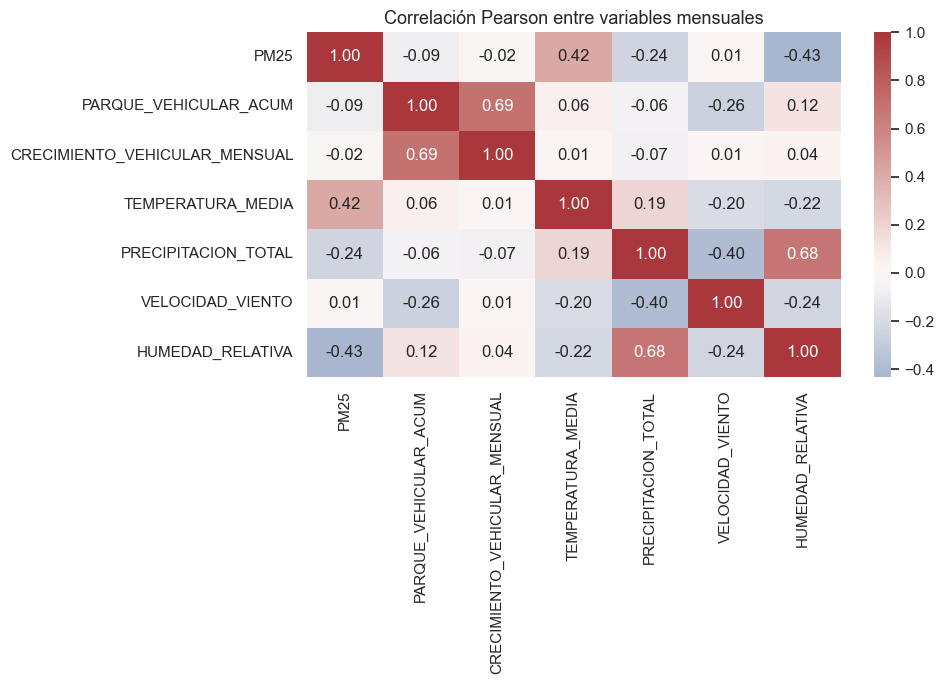

,PM25,PARQUE_VEHICULAR_ACUM,CRECIMIENTO_VEHICULAR_MENSUAL,TEMPERATURA_MEDIA,PRECIPITACION_TOTAL,VELOCIDAD_VIENTO,HUMEDAD_RELATIVA
PM25,1.0000,-0.0943,-0.0244,0.4175,-0.2418,0.0105,-0.4337
PARQUE_VEHICULAR_ACUM,-0.0943,1.0000,0.6928,0.0607,-0.0604,-0.2575,0.1225
CRECIMIENTO_VEHICULAR_MENSUAL,-0.0244,0.6928,1.0000,0.0053,-0.0749,0.0072,0.0412
TEMPERATURA_MEDIA,0.4175,0.0607,0.0053,1.0000,0.1934,-0.1971,-0.2247
PRECIPITACION_TOTAL,-0.2418,-0.0604,-0.0749,0.1934,1.0000,-0.4045,0.6806
VELOCIDAD_VIENTO,0.0105,-0.2575,0.0072,-0.1971,-0.4045,1.0000,-0.2370
HUMEDAD_RELATIVA,-0.4337,0.1225,0.0412,-0.2247,0.6806,-0.2370,1.0000


In [60]:
corr_matrix = df_monthly_clean[plot_cols].corr(method="pearson")
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlación Pearson entre variables mensuales")
plt.tight_layout(); plt.show()
display(corr_matrix)

## Pruebas de estacionariedad

La prueba Dickey-Fuller Aumentada, ADF, evalúa la hipótesis nula de raíz unitaria:

- H0: la serie no es estacionaria.
- H1: la serie es estacionaria.

Si p_value < 0.05, se rechaza H0 y se considera que la serie es estacionaria al 5%. También se calcula la primera diferencia para verificar si la diferenciación mejora la estacionariedad. En los modelos ARIMA/SARIMA, la diferenciación se incorpora mediante los parámetros d y D; por eso los modelos se ajustan sobre las series originales con órdenes de integración seleccionados, evitando doble diferenciación manual.

ADF en niveles:


,variable,n_obs,adf_statistic,p_value,used_lag,is_stationary_5pct,interpretation
5,PRECIPITACION_TOTAL,46,-5.8927,0.0000,6,True,Estacionaria
7,HUMEDAD_RELATIVA,46,-4.3531,0.0004,5,True,Estacionaria
6,VELOCIDAD_VIENTO,46,-3.7935,0.0030,2,True,Estacionaria
0,PM25,46,-3.4743,0.0087,1,True,Estacionaria
4,TEMPERATURA_MEDIA,46,-2.3183,0.1661,10,False,No estacionaria
3,CRECIMIENTO_VEHICULAR_MENSUAL,46,-0.0787,0.9515,5,False,No estacionaria
2,LOG_PARQUE_VEHICULAR_ACUM,46,1.3330,0.9968,1,False,No estacionaria
1,PARQUE_VEHICULAR_ACUM,46,5.2833,1.0000,1,False,No estacionaria


ADF en primera diferencia:


,variable,n_obs,adf_statistic,p_value,used_lag,is_stationary_5pct,interpretation
6,VELOCIDAD_VIENTO,45,-7.3227,0.0000,1,True,Estacionaria
2,LOG_PARQUE_VEHICULAR_ACUM,45,-6.1161,0.0000,0,True,Estacionaria
0,PM25,45,-5.5482,0.0000,0,True,Estacionaria
5,PRECIPITACION_TOTAL,45,-4.7804,0.0001,10,True,Estacionaria
3,CRECIMIENTO_VEHICULAR_MENSUAL,45,-4.6498,0.0001,4,True,Estacionaria
4,TEMPERATURA_MEDIA,45,-4.2873,0.0005,10,True,Estacionaria
7,HUMEDAD_RELATIVA,45,-4.1656,0.0008,10,True,Estacionaria
1,PARQUE_VEHICULAR_ACUM,45,-0.1705,0.9419,5,False,No estacionaria


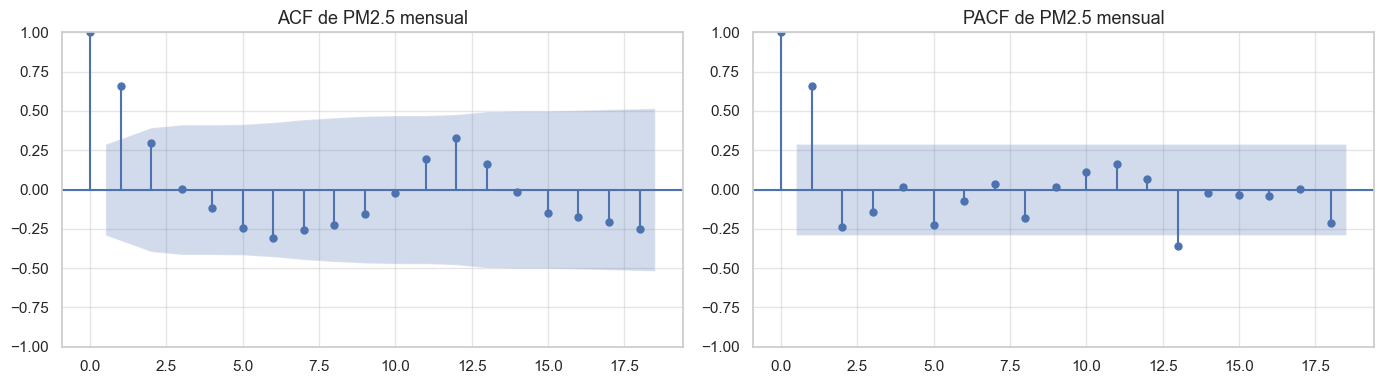

In [61]:
# ============================================================
# ADF en niveles y en primeras diferencias
# ============================================================

stationarity_cols = ["PM25", "PARQUE_VEHICULAR_ACUM", "LOG_PARQUE_VEHICULAR_ACUM", "CRECIMIENTO_VEHICULAR_MENSUAL", "TEMPERATURA_MEDIA", "PRECIPITACION_TOTAL", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]
adf_levels = run_adf_suite(df_monthly_clean, stationarity_cols)
print("ADF en niveles:")
display(adf_levels)

df_monthly_diff = df_monthly_clean[stationarity_cols].diff().dropna()
adf_first_diff = run_adf_suite(df_monthly_diff, stationarity_cols)
print("ADF en primera diferencia:")
display(adf_first_diff)

max_lags = min(18, max(6, len(df_monthly_clean) // 2 - 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_monthly_clean["PM25"], lags=max_lags, ax=axes[0]); axes[0].set_title("ACF de PM2.5 mensual")
plot_pacf(df_monthly_clean["PM25"], lags=max_lags, ax=axes[1], method="ywm"); axes[1].set_title("PACF de PM2.5 mensual")
plt.tight_layout(); plt.show()

# Fase 4: Modeling

El target siempre es PM2.5. La muestra mensual se divide cronológicamente en entrenamiento y prueba. Las variables exógenas se estandarizan usando solo el entrenamiento para evitar fuga de información y mejorar estabilidad numérica.

La estandarización implica que los coeficientes exógenos se interpretan como el cambio esperado en PM2.5 ante un aumento de una desviación estándar de la variable, manteniendo constantes las demás variables y la estructura temporal del modelo.

In [62]:
# ============================================================
# Dataset de modelado y partición temporal
# ============================================================

MODEL_COLUMNS = ["PM25", "PARQUE_VEHICULAR_ACUM", "TEMPERATURA_MEDIA", "PRECIPITACION_TOTAL", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]
model_df = df_monthly_clean[MODEL_COLUMNS].dropna().copy()
train_df, test_df = train_test_time_split(model_df, test_periods=12)

y_train = train_df["PM25"]
y_test = test_df["PM25"]
y_full = model_df["PM25"]

print("Rango entrenamiento:", train_df.index.min().date(), "a", train_df.index.max().date(), train_df.shape)
print("Rango prueba:", test_df.index.min().date(), "a", test_df.index.max().date(), test_df.shape)

Rango entrenamiento: 2022-03-01 a 2024-12-01 (34, 6)
Rango prueba: 2025-01-01 a 2025-12-01 (12, 6)


## Modelo 1: ARIMAX

Endógena: PM25.  
Exógena: PARQUE_VEHICULAR_ACUM.

La selección de hiperparámetros p, d, q intenta usar pmdarima.auto_arima si está disponible. Si no lo está, se ejecuta una búsqueda por grilla con statsmodels minimizando AIC.

Mejor orden ARIMAX: (0, 2, 0)


,method,order,seasonal_order,aic,bic
0,pmdarima.auto_arima,"(0, 2, 0)","(0, 0, 0, 0)",295.1400,298.0714


                               SARIMAX Results                                
Dep. Variable:                   PM25   No. Observations:                   34
Model:               SARIMAX(0, 2, 0)   Log Likelihood                -141.505
Date:                Fri, 12 Jun 2026   AIC                            289.010
Time:                        21:22:09   BIC                            293.312
Sample:                    03-01-2022   HQIC                           290.413
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept                -0.1187      4.506     -0.026      0.979      -8.950       8.712
PARQUE_VEHICULAR_ACUM  -126.2399    206.527     -0.611      0.541    -531.025     278.545
sigma2  

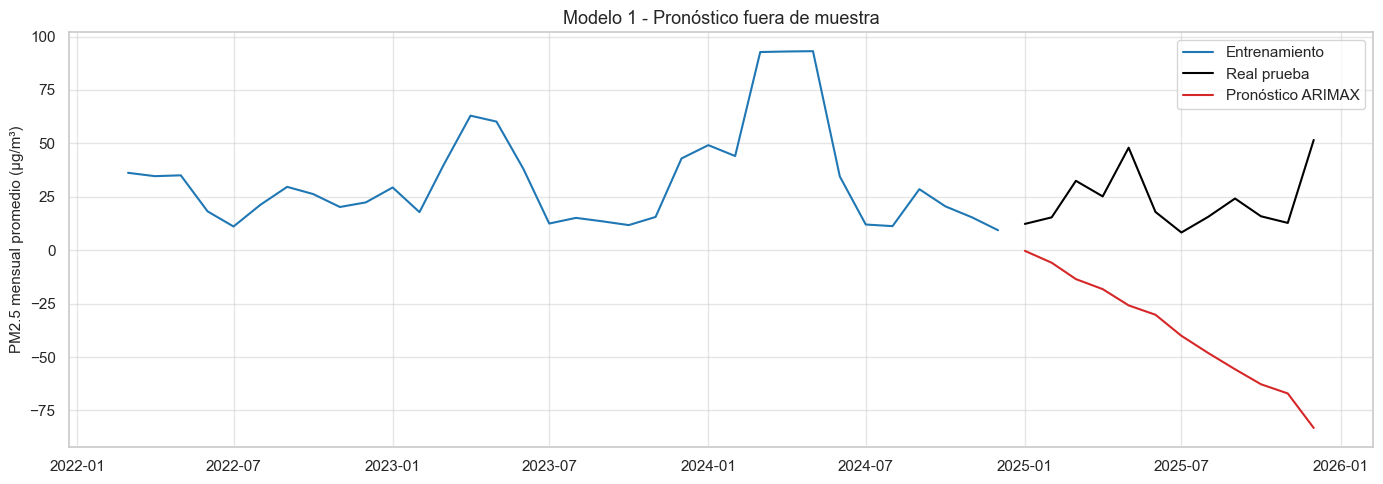

In [63]:
# ============================================================
# Modelo 1: ARIMAX con parque vehicular
# ============================================================

m1_exog_cols = ["PARQUE_VEHICULAR_ACUM"]
m1_x_train, m1_x_test, m1_x_full, m1_scaler = scale_exog(train_df[m1_exog_cols], test_df[m1_exog_cols], model_df[m1_exog_cols])

try:
    import pmdarima as pm
    auto_m1 = pm.auto_arima(y_train, X=m1_x_train, seasonal=False, start_p=0, start_q=0, max_p=4, max_q=4, d=None, test="adf", information_criterion="aic", stepwise=True, suppress_warnings=True, error_action="ignore", trace=False)
    best_order_m1 = auto_m1.order
    m1_search_results = pd.DataFrame([{"method": "pmdarima.auto_arima", "order": best_order_m1, "seasonal_order": (0, 0, 0, 0), "aic": auto_m1.aic(), "bic": auto_m1.bic()}])
except Exception as exc:
    print("pmdarima no disponible o falló. Se usará grid search con statsmodels.")
    print("Detalle:", exc)
    m1_search_results = sarimax_grid_search(y_train, m1_x_train, p_values=range(0, 3), d_values=range(0, 3), q_values=range(0, 3), seasonal_orders=[(0, 0, 0, 0)], criterion="aic")
    best_order_m1 = tuple(m1_search_results.loc[0, "order"])

print("Mejor orden ARIMAX:", best_order_m1)
display(m1_search_results.head(10))

m1_train_results = fit_sarimax_model(y_train, m1_x_train, order=best_order_m1, seasonal_order=(0, 0, 0, 0))
print(m1_train_results.summary())

m1_forecast = m1_train_results.get_forecast(steps=len(test_df), exog=m1_x_test).predicted_mean.rename("ARIMAX_forecast")
m1_metrics = evaluate_forecast(y_test, m1_forecast, "Modelo 1 - ARIMAX")
print(m1_metrics)

plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, label="Entrenamiento", color="tab:blue")
plt.plot(y_test.index, y_test, label="Real prueba", color="black")
plt.plot(m1_forecast.index, m1_forecast, label="Pronóstico ARIMAX", color="tab:red")
plt.title("Modelo 1 - Pronóstico fuera de muestra")
plt.ylabel("PM2.5 mensual promedio (μg/m³)")
plt.legend(); plt.tight_layout(); plt.show()

## Modelo 2: SARIMAX estacional

Endógena: PM25.  
Exógenas: PARQUE_VEHICULAR_ACUM, TEMPERATURA_MEDIA, PRECIPITACION_TOTAL, VELOCIDAD_VIENTO y HUMEDAD_RELATIVA.

Se asume estacionalidad anual mensual con s = 12. La búsqueda evalúa combinaciones pequeñas de P, D y Q para reducir sobreajuste en una muestra corta.

Mejor orden SARIMAX: (1, 1, 1)
Mejor orden estacional SARIMAX: (1, 1, 0, 12)


,order,seasonal_order,aic,bic,converged
0,"(1, 1, 1)","(1, 1, 0, 12)",-37.1302,-36.3358,False
1,"(1, 1, 1)","(0, 1, 1, 12)",36.7545,36.2136,True
2,"(0, 1, 1)","(0, 1, 1, 12)",43.9812,43.4944,True
3,"(0, 1, 0)","(1, 1, 0, 12)",44.2175,45.7953,True
4,"(1, 0, 1)","(1, 1, 0, 12)",44.2518,46.2241,True
5,"(1, 0, 1)","(0, 1, 1, 12)",48.9540,49.7484,False
6,"(1, 1, 0)","(1, 1, 0, 12)",50.0922,50.8072,True
7,"(0, 1, 0)","(0, 1, 1, 12)",52.3435,52.9791,True
8,"(1, 0, 0)","(0, 1, 1, 12)",52.6188,54.3938,True
9,"(1, 1, 0)","(0, 1, 1, 12)",54.1299,54.8448,True


                                      SARIMAX Results                                      
Dep. Variable:                                PM25   No. Observations:                   34
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                  28.565
Date:                             Fri, 12 Jun 2026   AIC                            -37.130
Time:                                     21:48:28   BIC                            -36.336
Sample:                                 03-01-2022   HQIC                           -42.488
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept               -11.9487      0.203    -58.847      0.000     -12.347     -1

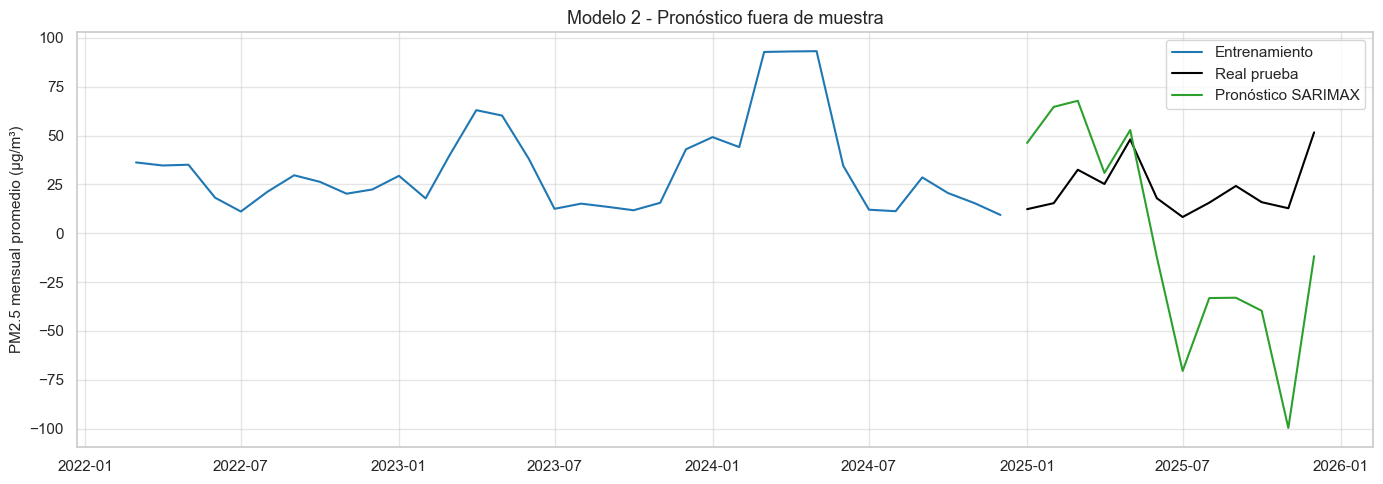

In [70]:
# ============================================================
# Modelo 2: SARIMAX con parque vehicular y clima
# ============================================================

m2_exog_cols = ["PARQUE_VEHICULAR_ACUM", "TEMPERATURA_MEDIA", "PRECIPITACION_TOTAL", "VELOCIDAD_VIENTO", "HUMEDAD_RELATIVA"]
m2_x_train, m2_x_test, m2_x_full, m2_scaler = scale_exog(train_df[m2_exog_cols], test_df[m2_exog_cols], model_df[m2_exog_cols])

seasonal_candidates = [(0, 0, 0, 12), (1, 0, 0, 12), (0, 0, 1, 12), (1, 0, 1, 12), (0, 1, 0, 12), (1, 1, 0, 12), (0, 1, 1, 12)]
m2_search_results = sarimax_grid_search(y_train, m2_x_train, p_values=range(0, 2), d_values=range(0, 2), q_values=range(0, 2), seasonal_orders=seasonal_candidates, criterion="aic")

best_order_m2 = tuple(m2_search_results.loc[0, "order"])
best_seasonal_order_m2 = tuple(m2_search_results.loc[0, "seasonal_order"])
print("Mejor orden SARIMAX:", best_order_m2)
print("Mejor orden estacional SARIMAX:", best_seasonal_order_m2)
display(m2_search_results.head(10))

m2_train_results = fit_sarimax_model(y_train, m2_x_train, order=best_order_m2, seasonal_order=best_seasonal_order_m2)
print(m2_train_results.summary())

m2_forecast = m2_train_results.get_forecast(steps=len(test_df), exog=m2_x_test).predicted_mean.rename("SARIMAX_forecast")
m2_metrics = evaluate_forecast(y_test, m2_forecast, "Modelo 2 - SARIMAX")
print(m2_metrics)

plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, label="Entrenamiento", color="tab:blue")
plt.plot(y_test.index, y_test, label="Real prueba", color="black")
plt.plot(m2_forecast.index, m2_forecast, label="Pronóstico SARIMAX", color="tab:green")
plt.title("Modelo 2 - Pronóstico fuera de muestra")
plt.ylabel("PM2.5 mensual promedio (μg/m³)")
plt.legend(); plt.tight_layout(); plt.show()

In [71]:
# ============================================================
# Reajuste final con toda la muestra para interpretación inferencial
# ============================================================

m1_full_results = fit_sarimax_model(y_full, m1_x_full, order=best_order_m1, seasonal_order=(0, 0, 0, 0))
m2_full_results = fit_sarimax_model(y_full, m2_x_full, order=best_order_m2, seasonal_order=best_seasonal_order_m2)

print("Resumen final Modelo 1 - ARIMAX")
print(m1_full_results.summary())
print("\n\nResumen final Modelo 2 - SARIMAX")
print(m2_full_results.summary())

Resumen final Modelo 1 - ARIMAX
                               SARIMAX Results                                
Dep. Variable:                   PM25   No. Observations:                   46
Model:               SARIMAX(0, 2, 0)   Log Likelihood                -195.532
Date:                Fri, 12 Jun 2026   AIC                            397.064
Time:                        21:48:30   BIC                            402.347
Sample:                    03-01-2022   HQIC                           399.012
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept                 0.3085      3.670      0.084      0.933      -6.884       7.501
PARQUE_VEHICULAR_ACUM   276.1349    150.265      1.838      0.066 

# Fase 5: Evaluation

Se comparan AIC, BIC, RMSE y MAE. El modelo ganador se selecciona principalmente por menor RMSE fuera de muestra; si los resultados son muy cercanos, se consideran AIC, BIC y parsimonia.

Después se diagnostican los residuales del modelo ganador con:

- Ljung-Box para autocorrelación residual.
- Jarque-Bera para normalidad.
- ARCH-LM para heterocedasticidad condicional.

,model,order,seasonal_order,aic_full,bic_full,n_test,rmse,mae
1,Modelo 2 - SARIMAX,"(1, 1, 1)","(1, 1, 0, 12)",168.0063,177.9636,12,55.8164,47.9348
0,Modelo 1 - ARIMAX,"(0, 2, 0)","(0, 0, 0, 0)",397.0638,402.3474,12,68.2391,60.8684


Modelo ganador por RMSE: Modelo 2 - SARIMAX


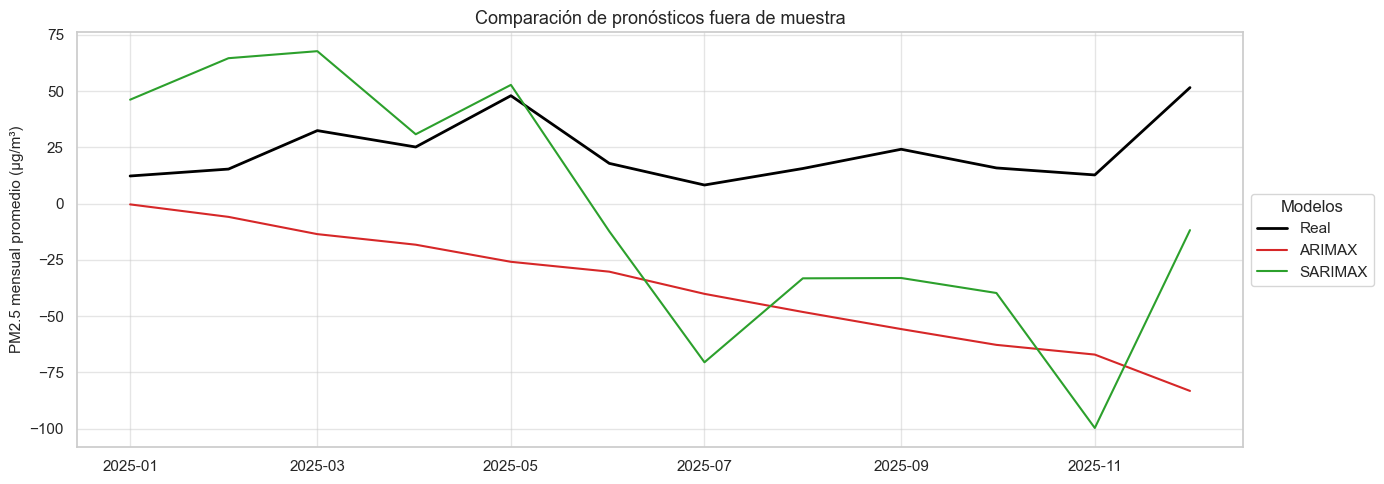

In [66]:
# ============================================================
# Comparación de modelos y selección del ganador
# ============================================================

comparison = pd.DataFrame([
    {"model": "Modelo 1 - ARIMAX", "order": best_order_m1, "seasonal_order": (0, 0, 0, 0), "aic_full": m1_full_results.aic, "bic_full": m1_full_results.bic, **{k: v for k, v in m1_metrics.items() if k != "model"}},
    {"model": "Modelo 2 - SARIMAX", "order": best_order_m2, "seasonal_order": best_seasonal_order_m2, "aic_full": m2_full_results.aic, "bic_full": m2_full_results.bic, **{k: v for k, v in m2_metrics.items() if k != "model"}},
]).sort_values(["rmse", "mae", "aic_full"])
display(comparison)

winner_name = comparison.iloc[0]["model"]
print("Modelo ganador por RMSE:", winner_name)
if winner_name == "Modelo 1 - ARIMAX":
    winner_full_results = m1_full_results
    winner_forecast = m1_forecast
else:
    winner_full_results = m2_full_results
    winner_forecast = m2_forecast

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label="Real", color="black", linewidth=2)
plt.plot(m1_forecast.index, m1_forecast, label="ARIMAX", color="tab:red")
plt.plot(m2_forecast.index, m2_forecast, label="SARIMAX", color="tab:green")
plt.title("Comparación de pronósticos fuera de muestra")
plt.ylabel("PM2.5 mensual promedio (μg/m³)")
plt.legend(title="Modelos", loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout();
plt.show()

,test,null_hypothesis,statistic,p_value,reject_H0_5pct
0,Ljung-Box lag 11,No autocorrelación residual,1.3723,0.9998,False
1,Jarque-Bera,Normalidad de residuales,956.0642,0.0000,True
2,ARCH-LM lag 6,Homocedasticidad condicional,1.0012,0.9856,False


plot_diagnostics no pudo ejecutarse: la serie es demasiado corta tras las diferenciaciones del modelo.
Los gráficos de diagnóstico equivalentes se generan a continuación.


<Figure size 1400x1000 with 0 Axes>

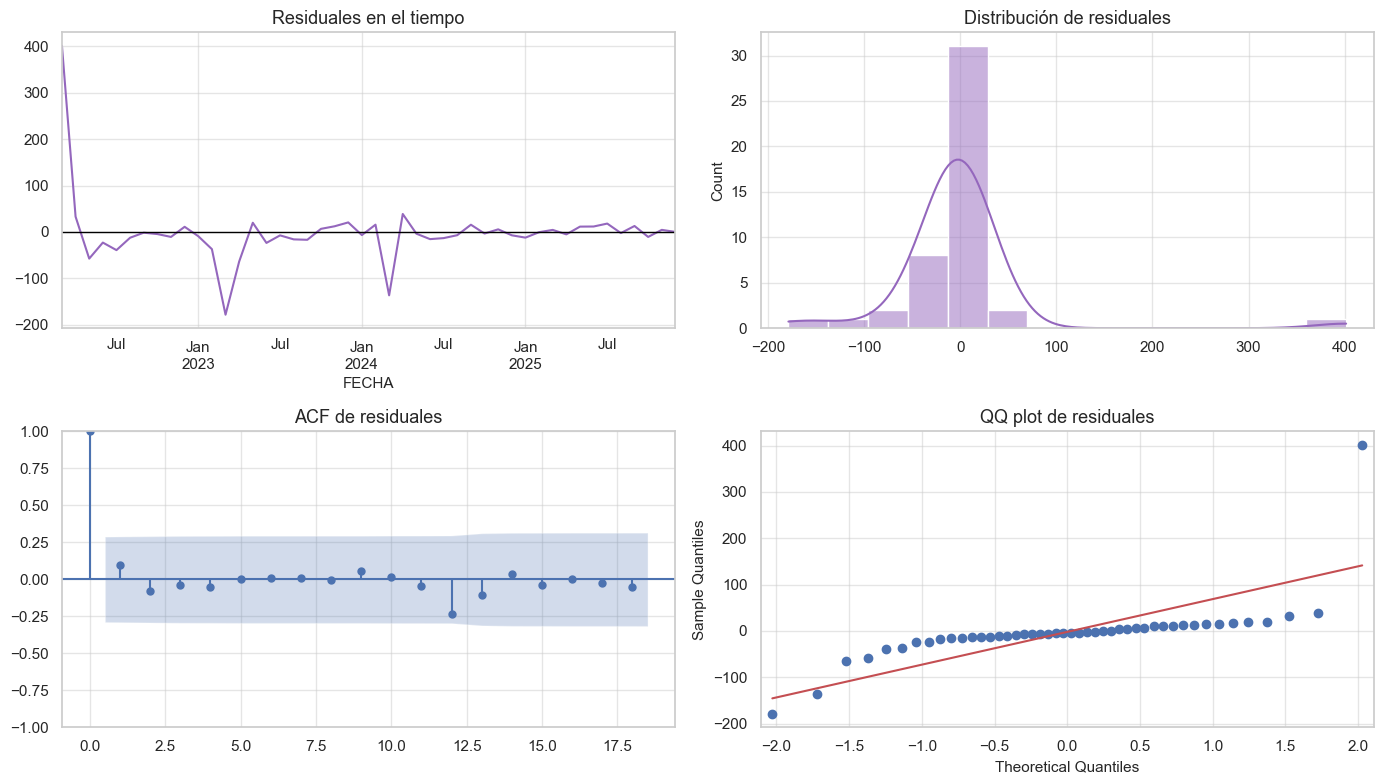

In [67]:
# ============================================================
# Diagnóstico de residuales del modelo ganador
# ============================================================

residuals = pd.Series(winner_full_results.resid, index=y_full.index).dropna()
residuals = residuals[np.isfinite(residuals)]

ljung_lag = min(12, max(1, len(residuals) // 4))
ljung_box = acorr_ljungbox(residuals, lags=[ljung_lag], return_df=True)
jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(residuals)
arch_lag = min(6, max(1, len(residuals) // 5))
arch_stat, arch_pvalue, _, _ = het_arch(residuals, nlags=arch_lag)

residual_tests = pd.DataFrame([
    {"test": f"Ljung-Box lag {ljung_lag}", "null_hypothesis": "No autocorrelación residual", "statistic": float(ljung_box["lb_stat"].iloc[0]), "p_value": float(ljung_box["lb_pvalue"].iloc[0])},
    {"test": "Jarque-Bera", "null_hypothesis": "Normalidad de residuales", "statistic": float(jb_stat), "p_value": float(jb_pvalue)},
    {"test": f"ARCH-LM lag {arch_lag}", "null_hypothesis": "Homocedasticidad condicional", "statistic": float(arch_stat), "p_value": float(arch_pvalue)},
])
residual_tests["reject_H0_5pct"] = residual_tests["p_value"] < 0.05
display(residual_tests)

# Gráfico integrado de statsmodels (puede fallar con series cortas y d alto)
try:
    winner_full_results.plot_diagnostics(figsize=(14, 10), lags=min(8, max(1, len(residuals) // 4)))
    plt.tight_layout(); plt.show()
except ValueError:
    print("plot_diagnostics no pudo ejecutarse: la serie es demasiado corta tras las diferenciaciones del modelo.")
    print("Los gráficos de diagnóstico equivalentes se generan a continuación.")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
residuals.plot(ax=axes[0, 0], color="tab:purple"); axes[0, 0].axhline(0, color="black", linewidth=1); axes[0, 0].set_title("Residuales en el tiempo")
sns.histplot(residuals, kde=True, ax=axes[0, 1], color="tab:purple"); axes[0, 1].set_title("Distribución de residuales")
plot_acf(residuals, lags=min(18, max(1, len(residuals) // 2 - 1)), ax=axes[1, 0]); axes[1, 0].set_title("ACF de residuales")
sm.qqplot(residuals, line="s", ax=axes[1, 1]); axes[1, 1].set_title("QQ plot de residuales")
plt.tight_layout(); plt.show()

# Fase 6: Deployment

En esta investigación, deployment significa dejar un procedimiento analítico reproducible y una interpretación técnica que pueda actualizarse con nuevos datos.

## Interpretación de coeficientes exógenos

Como las variables exógenas fueron estandarizadas, los coeficientes indican el cambio esperado en PM2.5 ante un aumento de una desviación estándar de la variable exógena, manteniendo constantes las demás variables y la estructura ARIMA/SARIMA.

Para el parque vehicular:

- Coeficiente positivo: meses con mayor parque vehicular acumulado se asocian con mayor PM2.5 esperado.
- Coeficiente negativo: asociación inversa, que puede reflejar confusión, composición vehicular, cambios tecnológicos, meteorología u omisión de variables relevantes.
- p_value < 0.05: evidencia estadística significativa al 5%.
- p_value >= 0.05: no hay evidencia suficiente para afirmar significancia estadística en esta especificación.

La significancia estadística no equivale por sí sola a causalidad. Para inferencia causal se recomienda incorporar controles adicionales, rezagos, eventos extraordinarios, fuentes no vehiculares, políticas públicas y, si existen, datos espaciales por estación.

In [68]:
# ============================================================
# Tablas de coeficientes e interpretación automática del efecto vehicular
# ============================================================

coef_m1 = coefficient_table(m1_full_results)
coef_m2 = coefficient_table(m2_full_results)
coef_winner = coefficient_table(winner_full_results)

print("Coeficientes Modelo 1 - ARIMAX")
display(coef_m1)
print("Coeficientes Modelo 2 - SARIMAX")
display(coef_m2)
print("Coeficientes del modelo ganador")
display(coef_winner)


def find_vehicle_parameter(coef_table: pd.DataFrame) -> Optional[str]:
    candidates = [idx for idx in coef_table.index if "PARQUE_VEHICULAR_ACUM" in str(idx)]
    return candidates[0] if candidates else None

summary_rows = []
for model_name, coef_table in [("Modelo 1 - ARIMAX", coef_m1), ("Modelo 2 - SARIMAX", coef_m2), ("Modelo ganador", coef_winner)]:
    param_name = find_vehicle_parameter(coef_table)
    if param_name is not None:
        row = coef_table.loc[param_name]
        summary_rows.append({"model": model_name, "parameter": param_name, "coef": row["coef"], "p_value": row["p_value"], "significant_5pct": row["significant_5pct"], "direction": "positiva" if row["coef"] > 0 else "negativa"})

vehicle_effect_summary = pd.DataFrame(summary_rows)
display(vehicle_effect_summary)

winner_vehicle = vehicle_effect_summary[vehicle_effect_summary["model"] == "Modelo ganador"]
if winner_vehicle.empty:
    print("No se identificó un parámetro explícito de parque vehicular en el modelo ganador.")
else:
    effect = winner_vehicle.iloc[0]
    print("CONCLUSIÓN TÉCNICA")
    print("- Modelo ganador:", winner_name)
    print(f"- Coeficiente del parque vehicular: {effect['coef']:.4f}")
    print(f"- Dirección de la asociación: {effect['direction']}")
    print(f"- p-valor: {effect['p_value']:.4f}")
    print("- ¿Relación estadísticamente significativa al 5%?:", "sí" if effect["significant_5pct"] else "no")
    if effect["significant_5pct"]:
        print("Interpretación: el modelo encuentra evidencia estadística de asociación entre parque vehicular y PM2.5. La dirección se interpreta según el signo del coeficiente.")
    else:
        print("Interpretación: con esta especificación no hay evidencia suficiente para afirmar una relación significativa al 5%. Esto no descarta una relación real; puede deberse a muestra corta, rezagos, variables omitidas o necesidad de una estrategia causal más completa.")

Coeficientes Modelo 1 - ARIMAX


,coef,std_error,z_or_t,p_value,ci_lower,ci_upper,significant_5pct
intercept,0.3085,3.6698,0.0841,0.9330,-6.8841,7.5011,False
PARQUE_VEHICULAR_ACUM,276.1349,150.2646,1.8377,0.0661,-18.3784,570.6482,False
sigma2,521.4773,103.3840,5.0441,0.0000,318.8485,724.1062,True


Coeficientes Modelo 2 - SARIMAX


,coef,std_error,z_or_t,p_value,ci_lower,ci_upper,significant_5pct
intercept,-10.4774,12.5744,-0.8332,0.4047,-35.1228,14.1679,False
PARQUE_VEHICULAR_ACUM,196.4315,200.3568,0.9804,0.3269,-196.2605,589.1236,False
TEMPERATURA_MEDIA,12.7340,12.8722,0.9893,0.3225,-12.4950,37.9630,False
PRECIPITACION_TOTAL,3.0933,9.5359,0.3244,0.7457,-15.5968,21.7833,False
VELOCIDAD_VIENTO,-8.5968,4.4737,-1.9216,0.0547,-17.3650,0.1715,False
HUMEDAD_RELATIVA,-2.0787,8.3410,-0.2492,0.8032,-18.4269,14.2694,False
ar.L1,-0.6112,1.0930,-0.5592,0.5760,-2.7534,1.5309,False
ma.L1,0.5241,1.2772,0.4103,0.6816,-1.9792,3.0274,False
ar.S.L12,-0.8080,0.2190,-3.6900,0.0002,-1.2371,-0.3788,True
sigma2,95.8253,71.4183,1.3417,0.1797,-44.1520,235.8027,False


Coeficientes del modelo ganador


,coef,std_error,z_or_t,p_value,ci_lower,ci_upper,significant_5pct
intercept,-10.4774,12.5744,-0.8332,0.4047,-35.1228,14.1679,False
PARQUE_VEHICULAR_ACUM,196.4315,200.3568,0.9804,0.3269,-196.2605,589.1236,False
TEMPERATURA_MEDIA,12.7340,12.8722,0.9893,0.3225,-12.4950,37.9630,False
PRECIPITACION_TOTAL,3.0933,9.5359,0.3244,0.7457,-15.5968,21.7833,False
VELOCIDAD_VIENTO,-8.5968,4.4737,-1.9216,0.0547,-17.3650,0.1715,False
HUMEDAD_RELATIVA,-2.0787,8.3410,-0.2492,0.8032,-18.4269,14.2694,False
ar.L1,-0.6112,1.0930,-0.5592,0.5760,-2.7534,1.5309,False
ma.L1,0.5241,1.2772,0.4103,0.6816,-1.9792,3.0274,False
ar.S.L12,-0.8080,0.2190,-3.6900,0.0002,-1.2371,-0.3788,True
sigma2,95.8253,71.4183,1.3417,0.1797,-44.1520,235.8027,False


,model,parameter,coef,p_value,significant_5pct,direction
0,Modelo 1 - ARIMAX,PARQUE_VEHICULAR_ACUM,276.1349,0.0661,False,positiva
1,Modelo 2 - SARIMAX,PARQUE_VEHICULAR_ACUM,196.4315,0.3269,False,positiva
2,Modelo ganador,PARQUE_VEHICULAR_ACUM,196.4315,0.3269,False,positiva


CONCLUSIÓN TÉCNICA
- Modelo ganador: Modelo 2 - SARIMAX
- Coeficiente del parque vehicular: 196.4315
- Dirección de la asociación: positiva
- p-valor: 0.3269
- ¿Relación estadísticamente significativa al 5%?: no
Interpretación: con esta especificación no hay evidencia suficiente para afirmar una relación significativa al 5%. Esto no descarta una relación real; puede deberse a muestra corta, rezagos, variables omitidas o necesidad de una estrategia causal más completa.


## Recomendaciones de robustez académica

Para fortalecer el capítulo metodológico y los anexos de la investigación se recomienda:

1. Evaluar rezagos del parque vehicular de 1 a 3 meses.
2. Comparar parque acumulado, crecimiento mensual, logaritmo del parque y tasa de crecimiento.
3. Controlar eventos extraordinarios como incendios, erupciones, quemas agrícolas, obras viales o cierres de tránsito.
4. Usar validación cruzada temporal tipo rolling-origin si el objetivo predictivo es central.
5. Comparar con modelos VAR, dynamic regression, Bayesian Structural Time Series o regresiones con errores HAC/Newey-West.
6. Repetir el análisis con precipitación promedio y total mensual para sensibilidad.

La siguiente celda exporta tablas clave para reproducibilidad, anexos y trazabilidad.

In [69]:
# ============================================================
# Exportación de resultados reproducibles
# ============================================================

OUTPUT_DIR = PROJECT_ROOT / "outputs_pm25_parque_vehicular"
OUTPUT_DIR.mkdir(exist_ok=True)

df_monthly_clean.to_csv(OUTPUT_DIR / "dataset_mensual_consolidado.csv", index=True, encoding="utf-8-sig")
adf_levels.to_csv(OUTPUT_DIR / "adf_niveles.csv", index=False, encoding="utf-8-sig")
adf_first_diff.to_csv(OUTPUT_DIR / "adf_primera_diferencia.csv", index=False, encoding="utf-8-sig")
comparison.to_csv(OUTPUT_DIR / "comparacion_modelos.csv", index=False, encoding="utf-8-sig")
residual_tests.to_csv(OUTPUT_DIR / "diagnostico_residuales.csv", index=False, encoding="utf-8-sig")
coef_m1.to_csv(OUTPUT_DIR / "coeficientes_modelo_1_arimax.csv", index=True, encoding="utf-8-sig")
coef_m2.to_csv(OUTPUT_DIR / "coeficientes_modelo_2_sarimax.csv", index=True, encoding="utf-8-sig")
vehicle_effect_summary.to_csv(OUTPUT_DIR / "resumen_efecto_parque_vehicular.csv", index=False, encoding="utf-8-sig")

print(f"Resultados exportados en: {OUTPUT_DIR}")

Resultados exportados en: C:\Users\james\Documents\Github\air-quality-vehicular-impact-analysis\outputs_pm25_parque_vehicular


In [2]:
# Generando el archivo Markdown con el prompt optimizado e integrado
prompt_content = """# PROMPT OPTIMIZADO PARA GENERACIÓN DE JUPYTER NOTEBOOK (CRISP-DM)

Actúa como un Data Scientist Senior y experto en análisis de datos ambientales y series de tiempo. Tu tarea es desarrollar el código completo, robusto y las explicaciones detalladas para un Jupyter Notebook (.ipynb) que servirá como base analítica para una investigación de maestría titulada:

**"ANÁLISIS DEL EFECTO DEL AUMENTO DEL PARQUE VEHICULAR LIVIANO Y EL DETERIORO DE LA CALIDAD DEL AIRE CON PM2.5 EN LA CIUDAD CAPITAL, GUATEMALA 2022-2025"**

El Notebook debe estructurarse estrictamente siguiendo las 6 fases de la metodología CRISP-DM. Escribe el resultado combinando bloques de código en Python (comentados, modularizados y listos para ejecutarse) y celdas de Markdown para las explicaciones teóricas, suposiciones estadísticas y análisis de resultados.

---

### CONTEXTO, DATASETS Y REGLAS DE NEGOCIO

Busco encontrar la relación estadística e impacto entre el crecimiento del parque vehicular (en su totalidad, por altas, por antigüedad y por tipo) y la concentración de material particulado fino (PM2.5).

#### Datasets Disponibles:
1. `PARQUE-VEHICULAR-LIVIANO-2007-2025-FULL.csv` (Periodicidad mensual).
   - Columnas: 'ANIO_ALZA', 'MES', 'MODELO_VEHICULO', 'LINEA_VEHICULO', 'TIPO_VEHICULO', 'USO_VEHICULO', 'MARCA_VEHICULO', 'CANTIDAD'.
   - *NOTA CRÍTICA:* La columna 'CANTIDAD' contiene el número de carros agrupado por fila. La cantidad de vehículos es un valor numérico a sumar (`sum()`), NO se calcula contando filas.
2. `PM25_DAIRY_FULL_2022_2025.csv` (Periodicidad diaria, Marzo 2022 - Diciembre 2025).
   - Columnas: 'YEAR', 'MONTH', 'DAY', 'PM25' (Medido en μg/m³).

#### Regla de Clasificación Tipo de Vehículo (`LIVIANO_PESADO`):
Debes crear una nueva columna categórica llamada `LIVIANO_PESADO` en el dataset vehicular basada estrictamente en la columna `TIPO_VEHICULO` usando las siguientes listas de mapeo:
- **LIVIANOS:** {"AUTOMOVIL", "AMBULANCIA", "JEEP", "PICK UP", "CARRO PARA GOLF", "CAMIONETA", "CAMIONETA AGRICOLA", "CAMIONETA SPORT", "CAMIONETILLA", "PANEL", "MICROBUS", "MICROBUS ESCOLAR", "MOTO", "SCOOTER", "TRIMOTO", "CUATRIMOTO", "LIMOSINA", "CARRO FUNEBRE", "VEHICULO RUSTICO", "GO-KART"}
- **PESADOS:** {"AUTOBUS", "AUTOBUS ESCOLARP", "BARREDORA INDUST", "BUS", "BUS ESCOLAR", "CABEZAL", "CAMION", "CAMION BOMBEROS", "CAMION CHASIS", "CAMION CISTERNA", "CAMION FRIGORIFICO", "CAMION FURGON", "CAMION GRUA", "CAMION MEZCLADOR", "CAMION PERFORADOR", "CAMION VOLTEO", "CISTERNA", "ESPARCIDORA", "FURGON", "GONDOLA", "GRANELERA", "GRUA", "GRUA HIDRAULICA", "JAULA CANERA", "LOW BOY", "MEZCLADORA", "MINIBUS", "OMNIBUS", "PERFORADORA", "PLATAFORMA", "PORTA CONTENEDOR", "RASTRA", "REMOLQUE", "RETROEXCAVADORA", "SEMI REMOLQUE", "TACUASINA", "TANQUE", "TOLBA", "TRACTO CAMION", "TRACTOR", "TRACTOR AGRICOLA", "TRACTOR CONSTRUC", "TRANS DE CARGA", "VOLQUETA", "PALANGANA", "ARA A", "CARRETA-CARRETON", "CAMIONETA ESCOLA", "MINI TRACTOR", "MINITRACTOR", "CASA RODANTE", "MONTA CARGA", "CARRETILLA-AUTOM", "COCHE VIVIENDA"}

---

### ESTRUCTURA DETALLADA DEL JUPYTER NOTEBOOK (CRISP-DM)

#### Fase 1: Business Understanding
- Define el objetivo del proyecto, las preguntas de investigación y las métricas de éxito del modelo estadístico (AIC, BIC, RMSE, MAE).
- Justifica el enfoque metodológico de análisis multivariado de series de tiempo y análisis correlacional segmentado.

#### Fase 2: Data Understanding
- **Carga de Datos:** Código en `pandas` para leer ambos archivos.
- **EDA Preliminar:** Inspección de tipos de datos, dimensiones, verificación de nulos y estadísticas descriptivas de las variables numéricas.
- **Visualización Inicial:** Grafica las series temporales en su estado crudo usando `matplotlib` o `seaborn` (PM2.5 diario/mensual y volumen vehicular mensual).

#### Fase 3: Data Preparation (Crucial)
Desarrolla el código necesario para realizar la transformación y alineación de los datos:
1. **Filtrado Temporal:** Restringe ambos datasets estrictamente al rango temporal donde coexisten los datos (Marzo 2022 a Diciembre 2024/2025 según disponibilidad, enfocando los análisis granulares específicamente en el periodo 2022-2024).
2. **Ingeniería de Características (Features):**
   - Aplica la regla de mapeo para crear la columna `LIVIANO_PESADO`.
   - Genera la métrica **ALTAS VEHICULARES:** Corresponde a la suma mensual directa de la columna `CANTIDAD` agrupada por año y mes.
   - Genera la métrica **ACUMULADO VEHICULAR:** Calcula la suma acumulativa en el tiempo (`cumsum()`) de las altas para reflejar el tamaño total del parque en circulación mes a mes.
3. **Agregación y Alineación Temporal:** Agrupa el dataset de PM2.5 calculando la **media mensual** para que sea perfectamente emparejable con la periodicidad del dataset vehicular. Genera un DataFrame maestro indexado por año y mes (`YYYY-MM`).
4. **Tratamiento de Series Temporales:** Ejecuta la Prueba de Dickey-Fuller Aumentada (ADF) para verificar la estacionariedad de las series principales (PM2.5, Altas Totales y Acumulado Total). Si no son estacionarias, aplica diferenciación e imprime los nuevos resultados de la prueba.

#### Fase 4: Modeling & Advanced Correlation Analysis
Divide esta fase en dos grandes bloques de modelado y análisis estadístico:

##### BLOQUE A: Análisis de Correlación Avanzada y Segmentada (Periodo 2022-2024)
Para entender la dinámica fina de los datos, genera matrices de correlación (Pearson y Spearman) y mapas de calor (`sns.heatmap`) cruzando el **PM2.5 Promedio Mensual** con las siguientes segmentaciones:
1. **Utilizando el ACUMULADO VEHICULAR (2022-2024) frente a PM2.5:**
   - **1.1. Por Modelo (Año de Fabricación):** Pivota el dataset para obtener el acumulado mensual de vehículos según la columna `MODELO_VEHICULO` y calcula su correlación con el PM2.5.
   - **1.2. Por Tipo de Vehículo:** Pivota el dataset para evaluar el acumulado mensual por categorías de `TIPO_VEHICULO` (ej. Camionetilla, Pick Up, Automóvil, etc.) contra PM2.5.
   - **1.3. Por Macro-Categoría (`LIVIANO_PESADO`):** Analiza la correlación del acumulado de vehículos clasificados como "LIVIANO" vs "PESADO" frente al PM2.5.
2. **Utilizando únicamente las ALTAS VEHICULARES (2022-2024) frente a PM2.5:**
   - **2.1. Por Modelo (Año de Fabricación):** Correlación de las altas mensuales según su `MODELO_VEHICULO` con el PM2.5.
   - **2.2. Por Tipo de Vehículo:** Correlación de las altas mensuales por cada `TIPO_VEHICULO` con el PM2.5.
   - **2.3. Por Macro-Categoría (`LIVIANO_PESADO`):** Correlación del flujo de nuevos vehículos clasificados como "LIVIANO" vs "PESADO" frente al PM2.5.

##### BLOQUE B: Modelado de Series de Tiempo Riguroso
Desarrolla e implementa dos modelos predictivos explicativos, donde la variable endógena (Target) es el PM2.5 mensual:
- **Modelo 1: ARIMAX:** Utiliza como variable exógena el Parque Vehicular (Altas o Acumulado según cuál haya mostrado mejor comportamiento o estacionariedad). Usa `pmdarima` (o gráficas ACF/PACF) para sintonizar los hiperparámetros `(p, d, q)` óptimos. Ajusta el modelo y muestra el `summary()`.
- **Modelo 2: SARIMAX:** Incorpora el componente estacional asumiendo ciclos anuales `(s=12)`. Identifica los parámetros `(P, D, Q, s)` óptimos, ajusta el modelo e imprime el `summary()`.

#### Fase 5: Evaluation
- Construye una tabla comparativa de rendimiento entre el modelo ARIMAX y SARIMAX utilizando los criterios de información **AIC** y **BIC** (menor es mejor).
- Calcula las métricas de error de pronóstico: **RMSE** y **MAE**.
- Realiza un análisis exhaustivo de los residuales del modelo ganador: aplica la **Prueba de Ljung-Box** para descartar autocorrelación, evalúa la normalidad (Prueba Jarque-Bera o Shapiro-Wilk) y la homocedasticidad. Dibuja los gráficos de diagnóstico estándar (Residuales vs. Tiempo, Histograma, QQ-Plot y ACF de residuales).

#### Fase 6: Deployment & Academic Insights
- Concluye el notebook con una sección de discusión técnica orientada a la redacción de la tesis.
- Interpreta de forma rigurosa los coeficientes físicos y estadísticos de las variables exógenas en los modelos.
- Explica detalladamente, basándote en los p-valores obtenidos en las matrices de correlación y en los modelos ARIMA/SARIMAX, si existe una **relación estadística significativa** entre el crecimiento/composición del parque vehicular (identificando qué tipos de vehículos, modelos antiguos/nuevos o si el flujo vs stock impacta más) y el deterioro de la calidad del aire por PM2.5 en la Ciudad de Guatemala.

---
Por favor, asegúrate de utilizar librerías estándar (`pandas`, `numpy`, `statsmodels`, `pmdarima`, `matplotlib`, `seaborn`, `scipy`). Todo el código debe venir libre de errores sintácticos, encapsulado lógicamente y listo para ejecutarse de manera secuencial."""

print(prompt_content)

# PROMPT OPTIMIZADO PARA GENERACIÓN DE JUPYTER NOTEBOOK (CRISP-DM)

Actúa como un Data Scientist Senior y experto en análisis de datos ambientales y series de tiempo. Tu tarea es desarrollar el código completo, robusto y las explicaciones detalladas para un Jupyter Notebook (.ipynb) que servirá como base analítica para una investigación de maestría titulada:

**"ANÁLISIS DEL EFECTO DEL AUMENTO DEL PARQUE VEHICULAR LIVIANO Y EL DETERIORO DE LA CALIDAD DEL AIRE CON PM2.5 EN LA CIUDAD CAPITAL, GUATEMALA 2022-2025"**

El Notebook debe estructurarse estrictamente siguiendo las 6 fases de la metodología CRISP-DM. Escribe el resultado combinando bloques de código en Python (comentados, modularizados y listos para ejecutarse) y celdas de Markdown para las explicaciones teóricas, suposiciones estadísticas y análisis de resultados.

---

### CONTEXTO, DATASETS Y REGLAS DE NEGOCIO

Busco encontrar la relación estadística e impacto entre el crecimiento del parque vehicular (en su totalidad, por al